<div style='text-align: center; padding: 30px'>
  <h1><strong>Time Series</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

Son muchas, solo vamos a plottear las que vamos a usar en nuestros portafolios.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
file = r'cryptos-index.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [71]:
weights = pd.read_csv('portfolio-cfd.csv')

In [ ]:
pcfd = data  # portfolio cfd

In [73]:
returns = pcfd.pct_change()
returns = returns.dropna()

In [ ]:
# get the weights 
for w in weights.columns:                       # for each crypto
    returns[w] = returns[w] * weights[w][0]     # multiply by the weight 

In [ ]:
returns['Portfolio'] = returns.sum(axis=1)    # sum the columns to get the portfolio return

Text(0.5, 1.0, 'Portfolio performance')

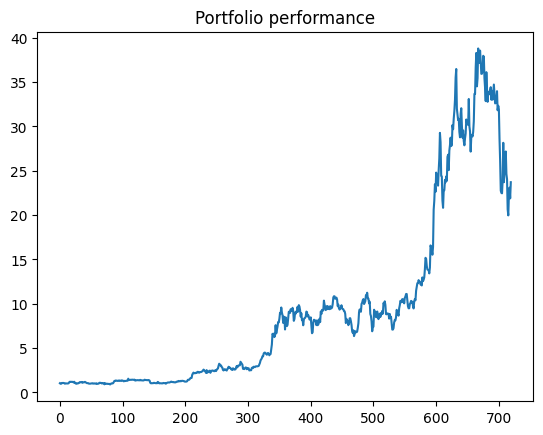

In [93]:
investment_list = []
investment = 1

for day in range(len(returns) - 720, len(returns)):
    investment = (1 + returns['Portfolio'].iloc[day]) * investment
    investment_list.append(investment)

# Plot the cumulative returns
plt.plot(investment_list)
plt.title('Portfolio performance')